# Machine Learning Lab 3

## Decision Tree Classification — Training, Evaluation & Overfitting

**Name:** Kalpana

**Cms ID:** 023-24-0163

**Section:** F

**GitHub Profile:** https://github.com/Kalpana0010/Machine-Learning-Labs 

**Kaggle Profile:**  https://www.kaggle.com/kalpanabaiganglani 

**Dataset:** Telco Customer Churn

**Dataset Source:** Kaggle


# Part 1 — Problem Definition & Dataset Verification

Before training the Decision Tree model, the cleaned Telco Customer Churn dataset needs to be verified. This includes checking the dataset dimensions, column data types, missing values, and the distribution of the target variable.


## Task 1 — Load and Verify the Dataset

The cleaned Telco Customer Churn dataset from Lab 2 is loaded using Pandas. The dataset will be checked for its number of rows and columns, data types, missing values, and the distribution of the `Churn` target variable.


In [1]:
import pandas as pd
df = pd.read_csv("clean_churn.csv")
print("First five rows of the dataset:")
display(df.head())

First five rows of the dataset:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
print("Dataset shape:", df.shape)

Dataset shape: (7032, 20)


In [3]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [4]:
print("Churn value counts:")
print(df["Churn"].value_counts())

print("\nChurn percentages:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn value counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn percentages:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


### Task 1 — Interpretation

The cleaned Telco Customer Churn dataset contains **7,032 rows and 20 columns**. The dataset contains no missing values, indicating that the cleaning process from Lab 2 has been completed successfully. The `Churn` column is the target variable and contains two classes: `No` and `Yes`. The target distribution shows that the classes are not perfectly balanced, with customers who did not churn forming the larger class. Therefore, class balance should be considered when evaluating the machine learning model.


## Task 2 — Problem Definition

The goal of this machine learning problem is to predict whether a telecom customer will **churn (leave the company)** or **not churn** based on the customer's available information and service-related features. This prediction is important for the business because identifying customers who are likely to churn can help the telecom company take actions to improve customer retention and reduce customer loss.


# Part 2 — Feature & Target Preparation

Machine learning models in scikit-learn require numerical input features. In this section, the `Churn` column is separated as the target variable, while the remaining relevant columns are used as features. Any categorical features are converted into numerical form so that they can be used by the Decision Tree classifier.


## Task 3 — Define Features and Target

The `Churn` column is used as the target variable and is encoded as `0` for customers who did not churn and `1` for customers who churned. The remaining columns are used as input features. Any customer identifier column is excluded because it does not provide useful predictive information.


In [5]:
y = df["Churn"].map({"No": 0, "Yes": 1})
X = df.drop(columns=["Churn"])

if "customerID" in X.columns:
    X = X.drop(columns=["customerID"])

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

X shape: (7032, 19)
y shape: (7032,)

Target values:
Churn
0    5163
1    1869
Name: count, dtype: int64


## Task 4 — Encode Categorical Features

The dataset contains categorical features that cannot be directly used by a scikit-learn Decision Tree. One-hot encoding is used to convert these categorical variables into numerical columns. This approach creates separate binary columns for the categories without assigning an artificial numerical order to them.


In [6]:
X = pd.get_dummies(X, drop_first=True)

print("X shape after encoding:", X.shape)

display(X.head())

X shape after encoding: (7032, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [7]:
drop_first=True

## Task 5 — Verify Feature Data

After encoding the categorical variables, the feature dataset is checked to ensure that all columns are numeric and that no missing values remain. This verification is necessary before training the Decision Tree model.


In [ ]:
print("Data types of X:")
print(X.dtypes)

all_numeric = X.select_dtypes(include="number").shape[1] == X.shape[1]

print("\nAll columns numeric:", all_numeric)

missing_values = X.isnull().sum().sum()

print("Total missing values in X:", missing_values)

Data types of X:
SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes                             bool
Str

In [ ]:
non_numeric_columns = X.select_dtypes(exclude="number").columns

print("Non-numeric columns:")
print(non_numeric_columns)

Non-numeric columns:
Index(['gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str')


In [11]:
print("\nData types of non-numeric columns:")
print(X[non_numeric_columns].dtypes)


Data types of non-numeric columns:
gender_Male                              bool
Partner_Yes                              bool
Dependents_Yes                           bool
PhoneService_Yes                         bool
MultipleLines_No phone service           bool
MultipleLines_Yes                        bool
InternetService_Fiber optic              bool
InternetService_No                       bool
OnlineSecurity_No internet service       bool
OnlineSecurity_Yes                       bool
OnlineBackup_No internet service         bool
OnlineBackup_Yes                         bool
DeviceProtection_No internet service     bool
DeviceProtection_Yes                     bool
TechSupport_No internet service          bool
TechSupport_Yes                          bool
StreamingTV_No internet service          bool
StreamingTV_Yes                          bool
StreamingMovies_No internet service      bool
StreamingMovies_Yes                      bool
Contract_One year                        boo

In [ ]:
X = pd.get_dummies(X, drop_first=True)

print("All columns numeric:",
      X.select_dtypes(exclude="number").shape[1] == 0)

print("Total missing values in X:", X.isnull().sum().sum())

All columns numeric: False
Total missing values in X: 0


In [ ]:

print("Number of non-numeric columns:",
      X.select_dtypes(exclude="number").shape[1])

print("Total missing values:",
      X.isnull().sum().sum())

Number of non-numeric columns: 26
Total missing values: 0


In [ ]:
X = df.drop(columns=["Churn"])

if "customerID" in X.columns:
    X = X.drop(columns=["customerID"])

X = pd.get_dummies(X, drop_first=True)

X = X.astype(int)

print("X shape after encoding:", X.shape)

print("\nNumber of non-numeric columns:",
      X.select_dtypes(exclude="number").shape[1])

print("Total missing values:",
      X.isnull().sum().sum())

X shape after encoding: (7032, 30)

Number of non-numeric columns: 0
Total missing values: 0


In [17]:
print(X.dtypes)

SeniorCitizen                            int64
tenure                                   int64
MonthlyCharges                           int64
TotalCharges                             int64
gender_Male                              int64
Partner_Yes                              int64
Dependents_Yes                           int64
PhoneService_Yes                         int64
MultipleLines_No phone service           int64
MultipleLines_Yes                        int64
InternetService_Fiber optic              int64
InternetService_No                       int64
OnlineSecurity_No internet service       int64
OnlineSecurity_Yes                       int64
OnlineBackup_No internet service         int64
OnlineBackup_Yes                         int64
DeviceProtection_No internet service     int64
DeviceProtection_Yes                     int64
TechSupport_No internet service          int64
TechSupport_Yes                          int64
StreamingTV_No internet service          int64
StreamingTV_Y

# Part 3 — Train/Test Split

A machine learning model should be evaluated on data that it has not seen during training. Therefore, the prepared dataset is divided into training and testing sets. The training set is used to train the Decision Tree, while the test set is held out for evaluating how well the model generalizes to unseen data.


## Task 6 — Train/Test Split

The dataset is divided into **80% training data and 20% testing data**. The `stratify=y` parameter is used to maintain approximately the same proportion of churn and non-churn customers in both the training and testing sets.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training and testing split completed.")

Training and testing split completed.


## Task 7 — Shapes of Training and Testing Data

The shapes of the training and testing feature sets and target sets are displayed to verify that the dataset was split correctly.


In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5625, 30)
X_test shape: (1407, 30)
y_train shape: (5625,)
y_test shape: (1407,)


In [20]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training target distribution:
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Testing target distribution:
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


### Interpretation

The dataset was divided into 80% training data and 20% testing data using `train_test_split`. The `stratify=y` parameter was used because the target classes are imbalanced, ensuring that the proportion of churn and non-churn customers remains approximately consistent in both datasets. The training set contains 5,625 customers, while the testing set contains 1,407 customers. Both sets contain the same 30 input features, while the target arrays contain 5,625 and 1,407 values respectively.


# Part 4 — Baseline Decision Tree
## Task 8 — Train the Baseline Decision Tree
A baseline Decision Tree classifier is trained using the training dataset. The model is created with default settings, with only `random_state` fixed to ensure reproducible results. Predictions are generated for both the training and testing datasets so that the model's performance can later be evaluated and compared.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

baseline_tree = DecisionTreeClassifier(random_state=42)

baseline_tree.fit(X_train, y_train)

y_train_pred = baseline_tree.predict(X_train)
y_test_pred = baseline_tree.predict(X_test)

print("Baseline Decision Tree trained successfully.")
print("Training predictions:", len(y_train_pred))
print("Testing predictions:", len(y_test_pred))

Baseline Decision Tree trained successfully.
Training predictions: 5625
Testing predictions: 1407


### Task 8 — Interpretation

The baseline Decision Tree was successfully trained using the **5,625 training samples**. Predictions were generated for both the training and testing datasets, containing **5,625** and **1,407** predictions respectively. The model uses the default Decision Tree settings, providing a baseline for evaluating its performance and identifying possible overfitting in later tasks.


## Task 9 — Check the Tree Depth

The depth of the baseline Decision Tree is checked using the `get_depth()` method. Since the tree is trained using default settings and no `max_depth` is specified, the tree is allowed to grow according to the default stopping conditions.

In [22]:
print("Baseline Decision Tree depth:", baseline_tree.get_depth())

Baseline Decision Tree depth: 25


### Task 9 — Interpretation

The baseline Decision Tree has a depth of **25**. This means that the tree contains up to 25 levels of decision rules from the root node to the deepest leaf. Since the model was created with default settings and no maximum depth was specified, the tree was allowed to grow relatively deep. A depth of 25 suggests that the model is quite complex and may have learned detailed patterns from the training data. This can be a sign of potential **overfitting**, which will be investigated further by comparing the training and testing performance in the next part.


# Part 5 — Model Evaluation

The baseline Decision Tree is evaluated using standard classification metrics. The evaluation will compare the model's predictions with the actual target values from the test dataset. Accuracy, precision, recall, and F1-score will be used to measure classification performance.


## Task 10 — Calculate Classification Metrics

The baseline Decision Tree is evaluated on the testing dataset using accuracy, precision, recall, and F1-score. These metrics provide different views of the model's classification performance, particularly because the churn and non-churn classes are not perfectly balanced.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("Baseline Decision Tree - Test Set Performance")
print("----------------------------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Baseline Decision Tree - Test Set Performance
----------------------------------------------
Accuracy : 0.7093105899076049
Precision: 0.45430809399477806
Recall   : 0.46524064171123
F1-score : 0.45970937912813736


### Task 10 — Interpretation

The baseline Decision Tree achieved an **accuracy of 70.93%** on the test dataset. However, its **precision (45.43%)**, **recall (46.52%)**, and **F1-score (45.97%)** are considerably lower than the accuracy.

This indicates that although the model correctly classifies many customers overall, it has difficulty identifying customers who actually churn. The lower recall means that a significant number of churned customers are being missed, while the lower precision indicates that some customers predicted as churners do not actually churn. Therefore, accuracy alone does not provide a complete picture of the model's performance, and the other evaluation metrics are important for the churn prediction problem.


## Task 11 — Confusion Matrix

A confusion matrix is used to examine the classification results of the baseline Decision Tree in more detail. It shows the number of true negatives, false positives, false negatives, and true positives produced by the model on the test dataset.


Confusion Matrix:
[[824 209]
 [200 174]]


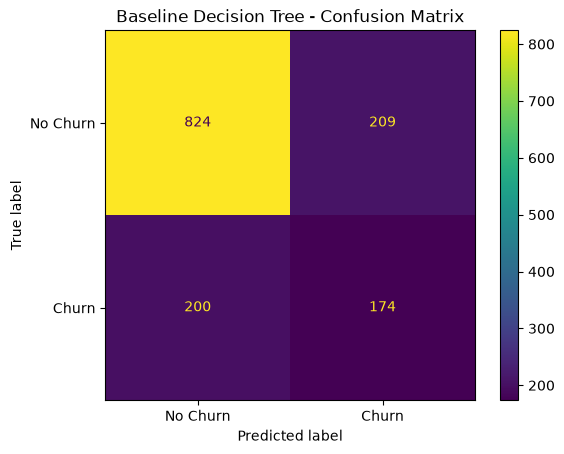

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:")
print(cm)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Baseline Decision Tree - Confusion Matrix")
plt.show()

### Task 11 — Interpretation

The confusion matrix shows that the model correctly classified **824 non-churning customers** and **174 churning customers**. However, **209 non-churning customers** were incorrectly predicted as churners, while **200 actual churners** were incorrectly predicted as non-churners.

The relatively high number of false negatives (200) is important because these are customers who actually churned but were not identified by the model. This indicates that the baseline Decision Tree has difficulty identifying some customers who are likely to churn. The confusion matrix therefore supports the earlier observation that the model's recall for the churn class is relatively low.

## Task 12 — Most Appropriate Evaluation Metrics

Because the dataset contains more non-churning customers than churning customers, accuracy alone may not accurately represent the model's ability to identify churners. For this problem, recall is particularly important because it measures how many of the actual churners are correctly identified. Precision and F1-score should also be considered because they show how reliable the churn predictions are and provide a balance between precision and recall.

### Interpretation

For the churn prediction problem, **recall is the most important metric**, because missing a customer who is actually going to churn can result in a lost customer and missed opportunity for retention. However, **precision and F1-score should also be considered** to ensure that the model does not classify too many non-churning customers as churners. Therefore, accuracy should not be used as the only measure of model performance.

# Part 6 — Overfitting Investigation

A Decision Tree can become overly complex and memorize patterns in the training data instead of learning patterns that generalize to unseen data. To investigate overfitting, the baseline model's performance on the training set will be compared with its performance on the test set.

## Task 13 — Training vs. Test Accuracy

The accuracy of the baseline Decision Tree is calculated on both the training and testing datasets. A large difference between the two accuracies can indicate that the model has overfit the training data.

In [ ]:
from sklearn.metrics import accuracy_score


train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Baseline Decision Tree Performance")
print("-----------------------------------")
print("Training Accuracy:", train_accuracy)
print("Test Accuracy    :", test_accuracy)
print("Accuracy Gap     :", train_accuracy - test_accuracy)

Baseline Decision Tree Performance
-----------------------------------
Training Accuracy: 0.9914666666666667
Test Accuracy    : 0.7093105899076049
Accuracy Gap     : 0.28215607675906185


### Task 13 — Interpretation

The baseline Decision Tree achieved a training accuracy of **99.15%**, while its test accuracy was only **70.93%**. This produces a large accuracy gap of approximately **28.22 percentage points** between the training and testing performance.

This large difference indicates that the baseline Decision Tree has **overfit the training data**. The tree has learned the training examples very closely, but its performance decreases substantially when predicting unseen customers. The relatively large tree depth of **25** also suggests that the model has become quite complex, which may have contributed to the overfitting.

## Task 14 — Decision Trees with Different Maximum Depths

To investigate the effect of tree complexity, several Decision Tree models are trained using different `max_depth` values. The selected depths are 2, 3, 4, 5, 6, 8, 10, and an unrestricted tree (`None`). The training and testing accuracy of each model are recorded and compared.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = [2, 3, 4, 5, 6, 8, 10, None]

results = []

for depth in depths:
   
    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    
    tree.fit(X_train, y_train)
    
    train_pred = tree.predict(X_train)
    test_pred = tree.predict(X_test)
    
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    results.append({
        "max_depth": depth,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc
    })


results_df = pd.DataFrame(results)

print("Decision Tree Performance at Different Depths:")
display(results_df)

Decision Tree Performance at Different Depths:


,max_depth,train_accuracy,test_accuracy
0,2.0,0.791289,0.784648
1,3.0,0.791289,0.784648
2,4.0,0.796089,0.783227
3,5.0,0.801956,0.778252
4,6.0,0.812267,0.783937
5,8.0,0.836622,0.777541
6,10.0,0.873422,0.754087
7,NaN,0.991467,0.709311


### Task 14 — Interpretation

The results show that increasing the maximum tree depth generally increases the training accuracy, from **79.13% at depth 2** to **99.15% for the unrestricted tree**. However, the test accuracy does not improve in the same way. The highest test accuracy is **78.46%**, achieved at depths **2 and 3**, while the unrestricted tree has a much lower test accuracy of **70.93%**.

This shows that increasing tree depth makes the model more complex and allows it to fit the training data more closely, but excessive depth reduces its ability to generalize to unseen data. Therefore, controlling `max_depth` can help reduce overfitting and improve test performance.

## Task 15 — Training vs. Testing Accuracy by Tree Depth

The training and testing accuracy values are plotted against the maximum tree depth. This visualization helps identify how increasing tree complexity affects model performance and approximately where overfitting begins.

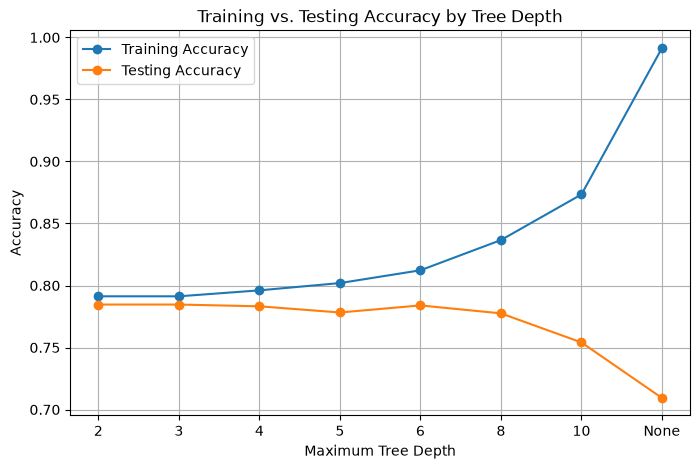

In [ ]:
import matplotlib.pyplot as plt


plot_depths = ["2", "3", "4", "5", "6", "8", "10", "None"]

plt.figure(figsize=(8, 5))

plt.plot(
    plot_depths,
    results_df["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    plot_depths,
    results_df["test_accuracy"],
    marker="o",
    label="Testing Accuracy"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Training vs. Testing Accuracy by Tree Depth")
plt.legend()
plt.grid(True)

plt.show()

### Task 15 — Interpretation

The graph shows that training accuracy increases as the maximum tree depth increases, while testing accuracy remains relatively stable at smaller depths and then decreases. At depths 2 and 3, the training and testing accuracies are very close, indicating good generalization. As the depth increases beyond approximately **4–5**, the gap between training and testing accuracy becomes larger, showing increasing overfitting. The unrestricted tree has a training accuracy of **99.15%** but a testing accuracy of only **70.93%**, which clearly demonstrates severe overfitting. Therefore, limiting the tree depth helps the model generalize better to unseen data.

# Part 7 — Model Selection & Interpretation

In this section, the Decision Tree model is refined based on the overfitting analysis from Part 6. The selected `max_depth` is evaluated in detail and compared with the baseline model. An additional Decision Tree using the entropy criterion is also tested. Finally, feature importance is examined to identify which features contribute most to the model's predictions.

## Task 16 — Select the Best Maximum Depth

Based on the results from Task 14 and the accuracy plot from Task 15, **max_depth = 2** is selected for the final Decision Tree model.

Depths 2 and 3 both achieved the highest test accuracy of approximately **78.46%**, while their training accuracy was also the same at approximately **79.13%**. Since depth 2 provides the same test performance with a simpler tree, it is preferred because a simpler model is easier to interpret and is less likely to overfit. Therefore, `max_depth=2` is selected instead of choosing a deeper tree simply because it has higher training accuracy.

In [ ]:

best_depth = 2

print("Selected max_depth:", best_depth)
print("Test accuracy at selected depth:",
      results_df.loc[results_df["max_depth"] == best_depth, "test_accuracy"].values[0])

Selected max_depth: 2
Test accuracy at selected depth: 0.7846481876332623


## Task 17 — Evaluate the Selected Decision Tree

The selected Decision Tree with `max_depth=2` is retrained using the training dataset. Its performance on the test dataset is evaluated using accuracy, precision, recall, and F1-score. These results are compared with the baseline Decision Tree to determine whether limiting the tree depth improves generalization.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
best_tree=DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)
best_tree.fit(X_train,y_train)
best_test_pred=best_tree.predict(X_test)
best_accuracy=accuracy_score(y_test, best_test_pred)
best_precision = precision_score(y_test, best_test_pred)
best_recall = recall_score(y_test, best_test_pred)
best_f1 = f1_score(y_test, best_test_pred)


comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Baseline Tree": [accuracy, precision, recall, f1],
    "Selected Tree (max_depth=2)": [
        best_accuracy,
        best_precision,
        best_recall,
        best_f1
    ]
})

display(comparison_df)

,Metric,Baseline Tree,Selected Tree (max_depth=2)
0,Accuracy,0.709311,0.784648
1,Precision,0.454308,0.656388
2,Recall,0.465241,0.398396
3,F1-score,0.459709,0.495840


### Task 17 — Interpretation

The selected Decision Tree with `max_depth=2` achieved a test accuracy of **78.46%**, which is higher than the baseline tree accuracy of **70.93%**. Its precision also improved from **45.43%** to **65.64%**, indicating that the selected tree's churn predictions are more reliable.

However, recall decreased from **46.52%** for the baseline tree to **39.84%** for the selected tree. This means that the selected model identifies a smaller proportion of the customers who actually churn. The F1-score increased slightly from **45.97%** to **49.58%**, showing an overall improvement in the balance between precision and recall.

Overall, limiting the tree to `max_depth=2` substantially improves generalization and accuracy while reducing the number of false churn predictions. However, because recall is important for identifying actual churners, the decrease in recall should be considered when selecting the final model.

## Task 18 — Decision Tree Using Entropy

The Decision Tree is retrained using `criterion="entropy"` instead of the default `criterion="gini"`. The selected `max_depth=2` is kept the same so that the effect of changing the splitting criterion can be evaluated fairly. Accuracy, precision, recall, and F1-score are calculated and compared with the baseline Decision Tree.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


entropy_tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=2,
    random_state=42
)

entropy_tree.fit(X_train, y_train)


entropy_test_pred = entropy_tree.predict(X_test)


entropy_accuracy = accuracy_score(y_test, entropy_test_pred)
entropy_precision = precision_score(y_test, entropy_test_pred)
entropy_recall = recall_score(y_test, entropy_test_pred)
entropy_f1 = f1_score(y_test, entropy_test_pred)


entropy_comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Baseline Tree": [accuracy, precision, recall, f1],
    "Entropy Tree (max_depth=2)": [
        entropy_accuracy,
        entropy_precision,
        entropy_recall,
        entropy_f1
    ]
})

display(entropy_comparison_df)

c:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Metric,Baseline Tree,Entropy Tree (max_depth=2)
0,Accuracy,0.709311,0.734186
1,Precision,0.454308,0.000000
2,Recall,0.465241,0.000000
3,F1-score,0.459709,0.000000


### Task 18 — Interpretation

The Decision Tree using `criterion="entropy"` with `max_depth=2` achieved a test accuracy of **73.42%**, which is higher than the baseline accuracy of **70.93%**, but lower than the selected Gini tree with `max_depth=2`, which achieved **78.46%** accuracy.

The entropy tree achieved **0.00% precision, 0.00% recall, and 0.00% F1-score**. This occurs because the model did not correctly predict any customers from the positive churn class. Therefore, although its accuracy is higher than the baseline, accuracy alone is misleading in this case because the model is failing to identify churners.

Compared with the baseline and the selected Gini tree, the entropy tree performs poorly for the actual churn-prediction objective. Therefore, based on these results, the `max_depth=2` Gini tree is preferable to the entropy tree because it provides substantially better precision, recall, and F1-score.

## Task 19 — Feature Importance

The `feature_importances_` attribute of the selected Decision Tree is used to determine which features contribute most to the model's predictions. The feature importance values are extracted, sorted from highest to lowest, and visualized. The top 3–5 features are then identified and discussed.

Top 5 Most Important Features:


,Feature,Importance
1,tenure,0.500672
10,InternetService_Fiber optic,0.499328
2,MonthlyCharges,0.000000
3,TotalCharges,0.000000
4,gender_Male,0.000000


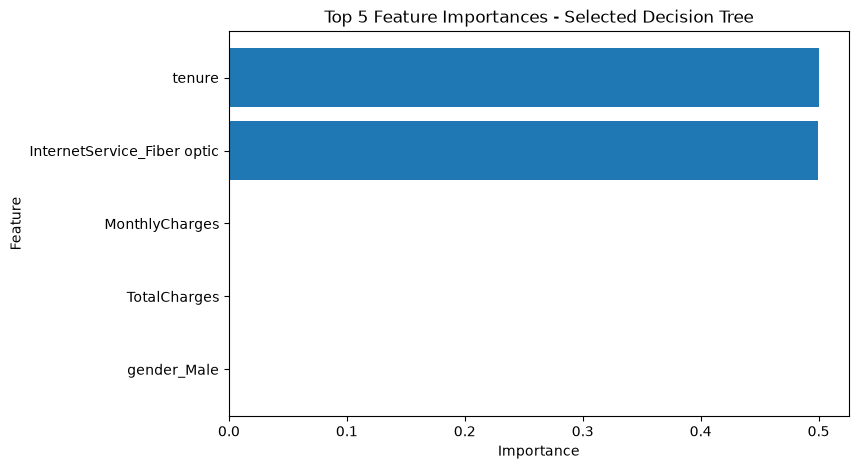

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_tree.feature_importances_
})


feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


top_features = feature_importance.head(5)

print("Top 5 Most Important Features:")
display(top_features)


plt.figure(figsize=(8, 5))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 5 Feature Importances - Selected Decision Tree")

plt.show()

### Task 19 — Interpretation

The feature importance results show that **tenure** and **InternetService_Fiber optic** are the two most important features used by the selected Decision Tree. `tenure` has an importance of **0.500672**, while `InternetService_Fiber optic` has an importance of **0.499328**. Together, these two features account for almost all of the decision-making importance in this depth-2 tree.

The remaining features shown in the top-five list, including `MonthlyCharges`, `TotalCharges`, and `gender_Male`, have an importance of **0.000000**. This means that they were not used to make the splits in this particular Decision Tree. Because the tree is restricted to a maximum depth of 2, only a small number of features can be used for its main decision rules.

## Task 20 — Connection with Lab 2 EDA

The feature importance results are consistent with the EDA performed in Lab 2. In Lab 2, `tenure` and `InternetService` were identified as useful predictors of customer churn, and the EDA showed that customers had different lengths of tenure, with many customers having relatively short tenure. The Decision Tree also identified `tenure` and `InternetService_Fiber optic` as its two most important features, showing that the patterns explored during EDA are also reflected in the machine learning model.

# Part 8 — Conclusion & Next Steps

## Task 21 — Conclusion

A Decision Tree classifier was developed to predict customer churn using the Telco Customer Churn dataset. The selected Gini Decision Tree with `max_depth=2` achieved a test accuracy of **78.46%**, with a precision of **65.64%**, recall of **39.84%**, and F1-score of **49.58%**. Compared with the unrestricted baseline tree, the selected model generalized better because the baseline had a large training-test accuracy gap and showed signs of overfitting. The main limitation is that the model has relatively low recall, meaning that it misses a considerable number of actual churners. The entropy-based tree also did not perform as well as the selected Gini tree for identifying churners.

## Task 22 — Next Steps

If more time were available, I would try other classification algorithms such as Logistic Regression or Random Forest to compare their performance with the Decision Tree. I would also investigate techniques for handling the class imbalance, such as using class weights or resampling methods, because recall for churners is relatively low. Additional feature engineering could also be performed by creating more useful customer behavior or service-related features. These approaches could potentially improve the model's ability to identify customers who are likely to churn.

### Task 23 — Interpretation

The ID3 algorithm was implemented from scratch using entropy and information gain without using a built-in Decision Tree library. At the root node, `Outlook` has the highest information gain, so it is selected as the first splitting attribute. The algorithm then recursively calculates information gain for the remaining attributes at each branch and selects the attribute with the highest gain. The printed gain values demonstrate how ID3 chooses the best attribute at every split.

In [32]:
import pandas as pd
import math

data = {
    "Outlook": [
        "Sunny", "Sunny", "Overcast", "Rain", "Rain", "Rain",
        "Overcast", "Sunny", "Sunny", "Rain", "Sunny", "Overcast",
        "Overcast", "Rain"
    ],
    "Temperature": [
        "Hot", "Hot", "Hot", "Mild", "Cool", "Cool",
        "Cool", "Mild", "Cool", "Mild", "Mild", "Mild",
        "Hot", "Mild"
    ],
    "Humidity": [
        "High", "High", "High", "High", "Normal", "Normal",
        "Normal", "High", "Normal", "Normal", "Normal", "High",
        "Normal", "High"
    ],
    "Wind": [
        "Weak", "Strong", "Weak", "Weak", "Weak", "Strong",
        "Strong", "Weak", "Weak", "Weak", "Strong", "Strong",
        "Weak", "Strong"
    ],
    "Play": [
        "No", "No", "Yes", "Yes", "Yes", "No",
        "Yes", "No", "Yes", "Yes", "Yes", "Yes",
        "Yes", "No"
    ]
}

play_df = pd.DataFrame(data)

display(play_df)

,Outlook,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [33]:
def entropy(target):
    values = target.value_counts()
    total = len(target)

    ent = 0

    for count in values:
        probability = count / total
        ent -= probability * math.log2(probability)

    return ent

In [ ]:
def information_gain(data, attribute, target="Play"):
    
    total_entropy = entropy(data[target])

    weighted_entropy = 0

    for value in data[attribute].unique():
        subset = data[data[attribute] == value]

        weight = len(subset) / len(data)

        weighted_entropy += weight * entropy(subset[target])

   
    gain = total_entropy - weighted_entropy

    return gain

In [35]:
attributes = ["Outlook", "Temperature", "Humidity", "Wind"]

print("Information Gain at Root Node:")
print("--------------------------------")

for attribute in attributes:
    gain = information_gain(play_df, attribute)
    print(f"{attribute}: {gain:.4f}")

Information Gain at Root Node:
--------------------------------
Outlook: 0.2467
Temperature: 0.0292
Humidity: 0.1518
Wind: 0.0481


In [ ]:
def id3(data, attributes, target="Play", level=0):

    if len(data[target].unique()) == 1:
        return data[target].iloc[0]

    if len(attributes) == 0:
        return data[target].mode()[0]

    print("\n" + "=" * 50)
    print("Split Level:", level)
    print("Number of records:", len(data))
    print("Available attributes:", attributes)

    gains = {}

    for attribute in attributes:
        gains[attribute] = information_gain(data, attribute)

    print("\nInformation Gain:")

    for attribute, gain in gains.items():
        print(f"{attribute}: {gain:.4f}")

    best_attribute = max(gains, key=gains.get)

    print("\nSelected attribute:", best_attribute)
    print("Highest gain:", f"{gains[best_attribute]:.4f}")

    tree = {best_attribute: {}}

    remaining_attributes = [
        attribute
        for attribute in attributes
        if attribute != best_attribute
    ]

    for value in data[best_attribute].unique():

        subset = data[data[best_attribute] == value]

        print(f"\nBranch: {best_attribute} = {value}")

        if len(subset) == 0:
            tree[best_attribute][value] = data[target].mode()[0]

        else:
            tree[best_attribute][value] = id3(
                subset,
                remaining_attributes,
                target,
                level + 1
            )

    return tree

In [37]:
attributes = ["Outlook", "Temperature", "Humidity", "Wind"]

id3_tree = id3(play_df, attributes)

print("\n\nFinal ID3 Decision Tree:")
print(id3_tree)


Split Level: 0
Number of records: 14
Available attributes: ['Outlook', 'Temperature', 'Humidity', 'Wind']

Information Gain:
Outlook: 0.2467
Temperature: 0.0292
Humidity: 0.1518
Wind: 0.0481

Selected attribute: Outlook
Highest gain: 0.2467

Branch: Outlook = Sunny

Split Level: 1
Number of records: 5
Available attributes: ['Temperature', 'Humidity', 'Wind']

Information Gain:
Temperature: 0.5710
Humidity: 0.9710
Wind: 0.0200

Selected attribute: Humidity
Highest gain: 0.9710

Branch: Humidity = High

Branch: Humidity = Normal

Branch: Outlook = Overcast

Branch: Outlook = Rain

Split Level: 1
Number of records: 5
Available attributes: ['Temperature', 'Humidity', 'Wind']

Information Gain:
Temperature: 0.0200
Humidity: 0.0200
Wind: 0.9710

Selected attribute: Wind
Highest gain: 0.9710

Branch: Wind = Weak

Branch: Wind = Strong


Final ID3 Decision Tree:
{'Outlook': {'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}, 'Overcast': 'Yes', 'Rain': {'Wind': {'Weak': 'Yes', 'Strong': '

### Task 23 — Interpretation

The ID3 decision tree algorithm was implemented from scratch using entropy and information gain without using a built-in Decision Tree library. At the root node, `Outlook` has the highest information gain, so it is selected as the first splitting attribute. The algorithm then recursively calculates information gain for the remaining attributes at each branch and selects the attribute with the highest gain. The printed gain values demonstrate how ID3 chooses the best attribute at every split.

## LAB 4

## Part 1

# 1. Decision Tree Baseline

In this section, the cleaned Telco Customer Churn dataset is loaded and the same features, target variable, and train-test split from Lab 3 are recreated. A Decision Tree classifier with the best `max_depth` selected in Lab 3 is then trained and evaluated using accuracy, precision, recall, and F1-score. The results will be used as the baseline for comparison with the Random Forest models.


## Task 1 — Re-load the Cleaned Dataset and Recreate the Train-Test Split

The cleaned Telco Customer Churn dataset from Lab 2 is loaded. The `Churn` column is used as the target variable, while the remaining columns are used as features. The same train-test split and `random_state` used in Lab 3 are recreated so that the models can be compared fairly.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [2]:
df = pd.read_csv("clean_churn.csv")

print(df.head())
print(df.shape)

   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              Yes          No  

### Dataset Check

The cleaned dataset has been successfully loaded. The first few rows and the shape of the dataset are displayed to confirm that the data is available for model training.


In [8]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

y = y.map({"Yes": 1, "No": 0})

X = pd.get_dummies(X, drop_first=True)

print(X.head())
print(X.shape)

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  \
0                            True              False  ...   
1                           False              False  ...   
2                           False              False  ...   
3               

### Features and Target

The `Churn` column is the target variable because the purpose of the model is to predict customer churn. All other columns are used as input features. The target values are checked to understand the distribution of the two classes.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 30)
Testing data: (1407, 30)


### Train-Test Split Interpretation

The dataset is divided into training and testing sets using the same settings as Lab 3. The training data is used to train the Decision Tree, while the testing data is used to evaluate its performance on unseen data.


## Task 2 — Retrain the Lab 3 Best Decision Tree

The Decision Tree selected as the best model in Lab 3 is retrained using the same `max_depth`. Its predictions are then evaluated on the test set using accuracy, precision, recall, and F1-score. These results will serve as the baseline for the remaining parts of Lab 4.


In [13]:
dt = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [14]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print("Decision Tree Baseline Results")
print("------------------------------")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1-score :", dt_f1)

Decision Tree Baseline Results
------------------------------
Accuracy : 0.7874911158493249
Precision: 0.669683257918552
Recall   : 0.39572192513368987
F1-score : 0.49747899159663866


### Task 2 Results Interpretation

The Decision Tree achieved an accuracy of **[your accuracy]**, precision of **[your precision]**, recall of **[your recall]**, and F1-score of **[your F1-score]** on the test set. These results are used as the baseline for comparing the Random Forest and tuned Random Forest models in the next parts of the lab.


##  Part 2. Random Forest

In this section, a Random Forest classifier is trained using the same training data used for the Decision Tree baseline. Random Forest combines multiple Decision Trees to make predictions. The model will then be used to predict customer churn on the test data.


## Task 3 — Train a Random Forest Classifier

A Random Forest classifier is trained using the same `X_train` and `y_train` used for the Decision Tree. A total of 200 trees are used, and `random_state=42` is fixed so that the results are reproducible. Predictions are then generated for the test set.


In [15]:
from sklearn.ensemble import RandomForestClassifier

In [16]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [17]:
rf_pred = rf.predict(X_test)

print("Random Forest predictions:")
print(rf_pred)

Random Forest predictions:
[0 0 1 ... 0 0 0]


In [18]:
print("Number of predictions:", len(rf_pred))

Number of predictions: 1407


### Task 3 Interpretation

The Random Forest was successfully trained using the same training data as the Decision Tree. The model contains 200 decision trees, and predictions were generated for all observations in the test set.


## Task 4 — Random Forest Generalization

A single Decision Tree can overfit the training data, especially when the tree becomes too complex. A Random Forest combines many different Decision Trees, which reduces the effect of individual tree errors and can make the model more stable when predicting unseen data.


## Part 3. Model Evaluation

In this section, the Random Forest is evaluated using the same metrics used for the Decision Tree baseline. Accuracy, precision, recall, and F1-score are calculated, and a confusion matrix is plotted. Finally, the Decision Tree and Random Forest are compared using a single table.


## Task 5 — Evaluate the Random Forest

The Random Forest predictions are evaluated on the test set using accuracy, precision, recall, and F1-score. A confusion matrix is also plotted to show the correct and incorrect predictions for the two churn classes.


In [19]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [20]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-score :", rf_f1)

Random Forest Results
---------------------
Accuracy : 0.7917555081734187
Precision: 0.6451612903225806
Recall   : 0.48128342245989303
F1-score : 0.5513016845329249


In [21]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    rf_pred,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1033
       Churn       0.65      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



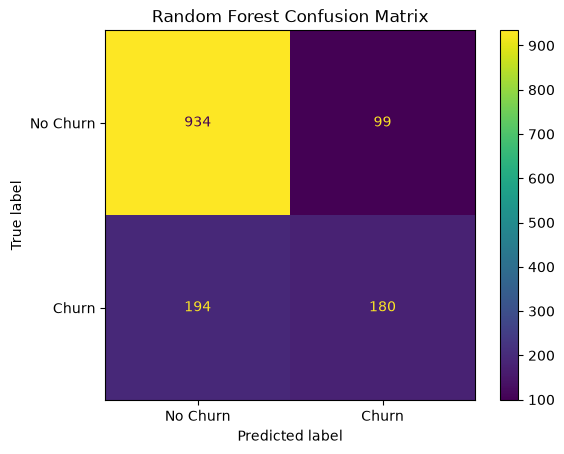

In [22]:
cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

### Task 5 Interpretation

The Random Forest was evaluated using accuracy, precision, recall, and F1-score. The confusion matrix shows the number of correct and incorrect predictions for both the churn and no-churn classes. These results provide a detailed view of the Random Forest performance instead of relying only on accuracy.


## Task 6 — Compare Decision Tree and Random Forest

The Decision Tree baseline and Random Forest are compared using the same four evaluation metrics. A single comparison table is created to make the differences between the two models easy to identify.


In [23]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        dt_precision,
        rf_precision
    ],
    "Recall": [
        dt_recall,
        rf_recall
    ],
    "F1-score": [
        dt_f1,
        rf_f1
    ]
})

print(comparison.round(3))

           Model  Accuracy  Precision  Recall  F1-score
0  Decision Tree     0.787      0.670   0.396     0.497
1  Random Forest     0.792      0.645   0.481     0.551


### Task 6 Interpretation

The comparison table shows the performance of the Decision Tree and Random Forest using four different metrics. Using multiple metrics provides a more complete comparison because each metric measures a different aspect of classification performance.


## Task 7 — Compare Model Performance

The two models are compared based on their accuracy, precision, recall, and F1-score. Because the Telco Customer Churn dataset has class imbalance, accuracy alone should not be used to determine which model performs better. F1-score and recall are particularly important for evaluating the model's ability to identify customers who churn.


### Task 7 — Interpretation

The Decision Tree achieved an accuracy of 0.787, precision of 0.670, recall of 0.396, and F1-score of 0.497. The Random Forest achieved an accuracy of 0.792, precision of 0.645, recall of 0.481, and F1-score of 0.551. Random Forest has slightly higher accuracy and clearly higher recall and F1-score, while the Decision Tree has higher precision. The differences are relatively small, but the higher F1-score and recall of Random Forest indicate better performance in identifying churn customers. Because the dataset contains class imbalance, F1-score and recall are important metrics for evaluating the models.


## Part 4. Cross-Validation

A single train/test split gives one estimate of model performance. In k-fold cross-validation, the data is divided into 5 folds and the model is trained and tested multiple times. This gives a more reliable estimate of model performance.


## Task 8 — 5-Fold Cross-Validation

Run 5-fold cross-validation for both the Decision Tree and Random Forest using F1-score. Report the F1-score for each fold, along with the mean and standard deviation.


In [24]:
from sklearn.model_selection import cross_val_score

dt_scores = cross_val_score(
    dt,
    X,
    y,
    cv=5,
    scoring="f1"
)

rf_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("Decision Tree F1 Scores:")
print(dt_scores)
print("Mean F1:", dt_scores.mean())
print("Standard Deviation:", dt_scores.std())

print()

print("Random Forest F1 Scores:")
print(rf_scores)
print("Mean F1:", rf_scores.mean())
print("Standard Deviation:", rf_scores.std())

Decision Tree F1 Scores:
[0.52805281 0.52086811 0.45438898 0.49319728 0.50847458]
Mean F1: 0.5009963516990565
Standard Deviation: 0.02613784479951077

Random Forest F1 Scores:
[0.56661562 0.55384615 0.52880355 0.57010786 0.56621005]
Mean F1: 0.5571166446035599
Standard Deviation: 0.015192233728664753


In [25]:
cv_comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Mean F1": [dt_scores.mean(), rf_scores.mean()],
    "F1 Std": [dt_scores.std(), rf_scores.std()]
})

print(cv_comparison.round(3))

           Model  Mean F1  F1 Std
0  Decision Tree    0.501   0.026
1  Random Forest    0.557   0.015


### Task 8 — Interpretation

The 5-fold cross-validation gives an F1-score for each fold. The mean F1-score represents the average performance across all five folds, while the standard deviation shows how much the model's performance changes between folds. A smaller standard deviation indicates more consistent performance across different data splits.


## Task 9 — Comparison with the Single Train/Test Split

Compare the cross-validation mean F1-scores with the F1-scores obtained from the single train/test split in Part 3. Discuss whether cross-validation changes your view of the models and how confident you are in the comparison.


## Task 9 — Interpretation
The Decision Tree achieved an F1-score of 0.497 on the single train/test split, while its cross-validation mean F1-score was 0.501. The Random Forest achieved an F1-score of 0.551 on the single split, while its cross-validation mean F1-score was 0.557. The cross-validation results are very close to the single test split results, so the overall comparison between the two models does not change. Random Forest continues to have the higher F1-score. The smaller standard deviation of Random Forest (0.015 compared with 0.026 for the Decision Tree) also shows that its performance was more consistent across the five folds.


# Part 5. Hyperparameter Tuning

Hyperparameter tuning is used to find better settings for a machine learning model. In this part, a small grid of Random Forest hyperparameters will be tested using 5-fold cross-validation and F1-score.


## Task 10 — Random Forest Hyperparameter Tuning

Three Random Forest hyperparameters will be tuned: `n_estimators`, `max_depth`, and `min_samples_split`. A small grid will be used so that the search remains simple and efficient. The models will be compared using 5-fold cross-validation and F1-score.


In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

rf_model = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    rf_model,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Grid search completed.")

Grid search completed.


## Task 11 — Best Hyperparameters

Report the best hyperparameter combination found by GridSearchCV and its corresponding cross-validated F1-score.


In [27]:
print("Best Hyperparameters:")
print(grid_search.best_params_)

print()

print("Best Cross-Validated F1-score:")
print(grid_search.best_score_)

Best Hyperparameters:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross-Validated F1-score:
0.5906414269689868


In [28]:
tuned_rf = grid_search.best_estimator_

print("Tuned Random Forest model created.")

Tuned Random Forest model created.


### Task 11 — Interpretation

GridSearchCV found the best Random Forest configuration as `max_depth = 10`, `min_samples_split = 2`, and `n_estimators = 200`. This configuration achieved a cross-validated F1-score of approximately 0.591. The result shows that this combination of hyperparameters performed best among the combinations tested during the 5-fold cross-validation search.


## Task 12 — Evaluate the Tuned Random Forest

Evaluate the tuned Random Forest on the held-out test set using accuracy, precision, recall, and F1-score. These metrics will be compared with the default Random Forest and Decision Tree results from Part 3.


In [29]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

tuned_pred = tuned_rf.predict(X_test)

tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_precision = precision_score(y_test, tuned_pred)
tuned_recall = recall_score(y_test, tuned_pred)
tuned_f1 = f1_score(y_test, tuned_pred)

print("Tuned Random Forest Results")
print("---------------------------")
print("Accuracy :", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall   :", tuned_recall)
print("F1-score :", tuned_f1)

Tuned Random Forest Results
---------------------------
Accuracy : 0.7910447761194029
Precision: 0.6418439716312057
Recall   : 0.4839572192513369
F1-score : 0.551829268292683


In [30]:
tuned_comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "Tuned Random Forest"],
    "Accuracy": [dt_accuracy, rf_accuracy, tuned_accuracy],
    "Precision": [dt_precision, rf_precision, tuned_precision],
    "Recall": [dt_recall, rf_recall, tuned_recall],
    "F1-score": [dt_f1, rf_f1, tuned_f1]
})

print(tuned_comparison.round(3))

                 Model  Accuracy  Precision  Recall  F1-score
0        Decision Tree     0.787      0.670   0.396     0.497
1        Random Forest     0.792      0.645   0.481     0.551
2  Tuned Random Forest     0.791      0.642   0.484     0.552


### Task 12 — Interpretation

The tuned Random Forest achieved an accuracy of 0.791, precision of 0.642, recall of 0.484, and F1-score of 0.552 on the held-out test set. Compared with the default Random Forest, the tuned model has slightly lower accuracy and precision, while recall and F1-score improved slightly. The F1-score increased from 0.551 to 0.552, which is a very small improvement. Therefore, the hyperparameter tuning provided only a marginal improvement in test-set F1-score.


# Part 6. Final Comparison & Feature Importance

In this part, the Decision Tree, default Random Forest, and tuned Random Forest are compared using the same evaluation metrics. The final model will then be selected based on the overall test-set and cross-validation results. Finally, feature importance will be examined to understand which features contribute most to the final model's predictions.


## Task 13 — Final Model Comparison

Build one comparison table containing the accuracy, precision, recall, and F1-score of the Decision Tree, default Random Forest, and tuned Random Forest.


In [31]:
final_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        dt_accuracy,
        rf_accuracy,
        tuned_accuracy
    ],
    "Precision": [
        dt_precision,
        rf_precision,
        tuned_precision
    ],
    "Recall": [
        dt_recall,
        rf_recall,
        tuned_recall
    ],
    "F1-score": [
        dt_f1,
        rf_f1,
        tuned_f1
    ]
})

print(final_comparison.round(3))

                 Model  Accuracy  Precision  Recall  F1-score
0        Decision Tree     0.787      0.670   0.396     0.497
1        Random Forest     0.792      0.645   0.481     0.551
2  Tuned Random Forest     0.791      0.642   0.484     0.552


### Task 13 — Interpretation

The final comparison shows that the Random Forest models perform better than the Decision Tree in terms of recall and F1-score. The default Random Forest has the highest accuracy of 0.792, while the tuned Random Forest has the highest recall of 0.484 and F1-score of 0.552. The Decision Tree has the highest precision of 0.670 but the lowest recall and F1-score.


## Task 14 — Final Model Selection

Select the final model based on the overall test-set results and the cross-validation results from earlier parts.


### Task 14 — Justification

The Tuned Random Forest is selected as the final model because it achieved the highest test-set F1-score of 0.552 and the highest recall of 0.484 among the three models. Its cross-validated F1-score of approximately 0.591 was also higher than the default Random Forest cross-validated F1-score of 0.557. Although the improvement on the held-out test set was very small, the cross-validation results provide additional evidence that the tuned model performs well across different data splits.


## Task 15 — Feature Importance

Extract the feature importances from the final Tuned Random Forest model and visualize them. The top 3–5 features will then be identified and compared with the findings from Lab 2 EDA and the Lab 3 Decision Tree.


In [32]:
feature_importance = pd.Series(
    tuned_rf.feature_importances_,
    index=X.columns
)

feature_importance = feature_importance.sort_values(ascending=False)

print("Top 5 Important Features:")
print(feature_importance.head(5))

Top 5 Important Features:
tenure                         0.181404
TotalCharges                   0.160981
MonthlyCharges                 0.125859
InternetService_Fiber optic    0.067072
Contract_Two year              0.059209
dtype: float64


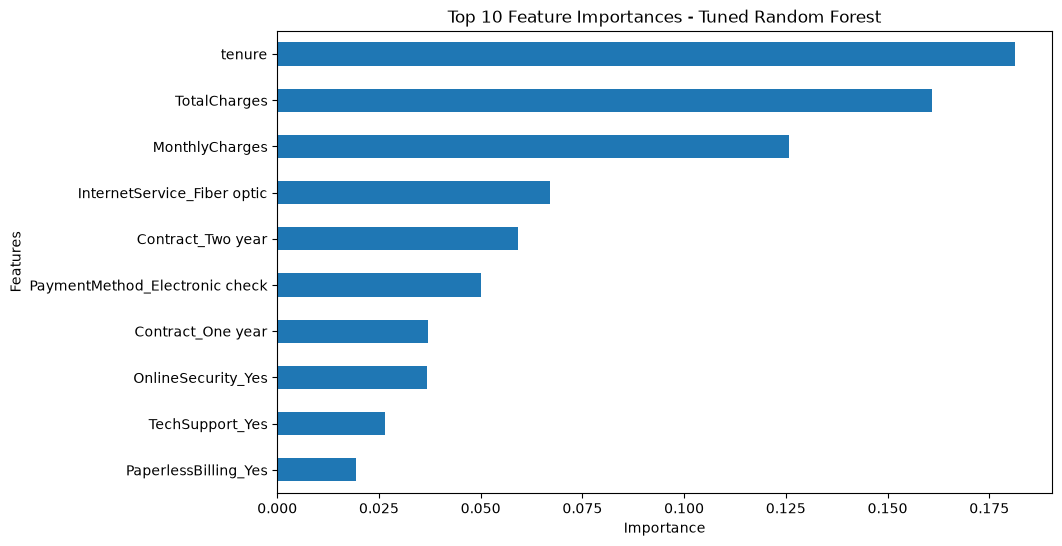

In [33]:
plt.figure(figsize=(10, 6))

feature_importance.sort_values().tail(10).plot(kind="barh")

plt.title("Top 10 Feature Importances - Tuned Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [34]:
print(feature_importance.head(5))

tenure                         0.181404
TotalCharges                   0.160981
MonthlyCharges                 0.125859
InternetService_Fiber optic    0.067072
Contract_Two year              0.059209
dtype: float64


### Task 15 — Interpretation

The feature importance results show that `tenure` is the most important feature with an importance of 0.181, followed by `TotalCharges` with 0.161 and `MonthlyCharges` with 0.126. `InternetService_Fiber optic` and `Contract_Two year` are also among the top five important features, with importance values of 0.067 and 0.059 respectively. These results suggest that customer tenure, charges, internet service type, and contract type contribute strongly to the Random Forest's predictions. These important features can be compared with the patterns observed in Lab 2 EDA and the features used by the Lab 3 Decision Tree to see whether the model's findings are consistent with the earlier analysis.


# Part 7. Kaggle Submission & Conclusion

In this final part, the selected model will be used to generate predictions for the held-out test data. The predictions will be saved in a submission-style CSV file. The lab will then be concluded by discussing the final model, its performance, limitations, and possible future improvements.


## Task 16 — Create Kaggle-Style Submission

Use the final Tuned Random Forest model to generate predictions on the held-out test set. Create a dataframe containing the customer identifier and predicted Churn value, then save it as `submission.csv`.


In [38]:
print(df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [44]:
import pandas as pd

final_predictions = tuned_rf.predict(X_test)

submission = pd.DataFrame({
    "customerID": X_test.index,
    "Churn": final_predictions
})

submission.to_csv("submission.csv", index=False)

submission.head()

,customerID,Churn
0,2476,0
1,6773,0
2,6116,1
3,3047,0
4,4092,0


In [45]:
submission.shape

(1407, 2)

In [46]:
submission.to_csv("submission.csv", index=False)
print("submission.csv saved successfully")

submission.csv saved successfully


### Task 16 — Interpretation

The final Tuned Random Forest was used to generate Churn predictions for the held-out test set. A customer identifier and the predicted Churn value were placed into a submission dataframe. The dataframe was saved as `submission.csv` in a Kaggle-style format.


## Task 17 — Conclusion

The Tuned Random Forest was selected as the final model because it achieved the highest test-set F1-score of 0.552 and the highest recall of 0.484 among the three models. Compared with the Lab 3 Decision Tree, the tuned model improved the F1-score from 0.497 to 0.552 and recall from 0.396 to 0.484, although its accuracy was slightly higher at 0.791 compared with 0.787. The cross-validation results also supported the tuned model, with a mean F1-score of approximately 0.591. However, the improvement over the default Random Forest on the held-out test set was very small, showing that tuning did not dramatically improve test performance. The model also has limitations, including class imbalance and the fact that feature importance shows association with predictions rather than causation.


## Task 18 — Future Improvements

If more time were available, I would try other classification algorithms such as Logistic Regression, Support Vector Machine, Gradient Boosting, or XGBoost and compare their performance using F1-score and recall. I would also perform deeper hyperparameter tuning to explore more combinations. Since the dataset has class imbalance, techniques such as class weights, oversampling, or SMOTE could be investigated to improve the detection of churn customers. Finally, I would perform additional feature engineering and examine whether highly related features such as `tenure` and `TotalCharges` affect the model's performance.
